# Comparing Pretrained Convolutional Neural Networks (CNNs) vs. Vision Transformer (ViTs)

This repository provides a comprehensive codebase for comparing a pretrained Convolutional Neural Network (ResNet18) and a Vision Transformer (ViT-B/16) on multiple vision datasets including CIFAR-10, MNIST, CIFAR-100, and EMNIST. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
import time

# Data Loading and Preprocessing

This section describes the process for loading and preprocessing datasets to ensure compatibility with pretrained models such as ResNet18 and ViT-B/16. Since these models are pretrained on ImageNet (224×224 RGB images with specific normalization), the datasets must be resized and normalized accordingly.

## Key Features

- **Resize to 224×224:**  
  All images are resized to 224×224 pixels to match the input requirements of the pretrained models.

- **Channel Conversion:**  
  Grayscale datasets (MNIST and EMNIST) are converted to 3-channel images so that they conform to the expected RGB format.

- **Normalization:**  
  Images are normalized using the ImageNet mean `[0.485, 0.456, 0.406]` and standard deviation `[0.229, 0.224, 0.225]`, ensuring consistency with the pretrained weights.

- **Dataset Support:**  
  The function supports CIFAR-10, CIFAR-100, MNIST, and EMNIST.

*Note:* Although data augmentation (e.g., random crop or horizontal flip) can be added—especially for datasets like CIFAR-10 and CIFAR-100—the current implementation applies the same transforms for both training and testing for clarity.


In [ ]:
# ImageNet normalization parameters.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_dataloaders(dataset_name, batch_size=64, data_dir='./data'):
    """
    Load and preprocess datasets: supports CIFAR-10, CIFAR-100, MNIST, and EMNIST.
    
    Parameters:
      - dataset_name (str): One of ['cifar10', 'cifar100', 'mnist', 'emnist'].
      - batch_size (int): Batch size for the data loader.
      - data_dir (str): Directory where the data will be downloaded or is stored.
    
    Returns:
      - train_loader (DataLoader): DataLoader for training data.
      - test_loader (DataLoader): DataLoader for testing data.
    """
    ds_name = dataset_name.lower()
    if ds_name == 'cifar10':
        train_ds = datasets.CIFAR10(root=data_dir, train=True, download=True)
        test_ds  = datasets.CIFAR10(root=data_dir, train=False, download=True)
    elif ds_name == 'cifar100':
        train_ds = datasets.CIFAR100(root=data_dir, train=True, download=True)
        test_ds  = datasets.CIFAR100(root=data_dir, train=False, download=True)
    elif ds_name == 'mnist':
        train_ds = datasets.MNIST(root=data_dir, train=True, download=True)
        test_ds  = datasets.MNIST(root=data_dir, train=False, download=True)
    elif ds_name == 'emnist':
        train_ds = datasets.EMNIST(root=data_dir, split='balanced', train=True, download=True)
        test_ds  = datasets.EMNIST(root=data_dir, split='balanced', train=False, download=True)
    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    # Define common transforms: resize images, convert grayscale images to 3 channels if needed, convert to tensor,
    # and apply ImageNet normalization.
    common_transforms = [transforms.Resize(224)]
    if ds_name in ['mnist', 'emnist']:
        common_transforms.append(transforms.Grayscale(num_output_channels=3))
    common_transforms += [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]
    transform = transforms.Compose(common_transforms)
    
    # Attach the transform to each dataset.
    train_ds.transform = transform
    test_ds.transform = transform
    
    # Create DataLoaders.
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

## Model Setup (Pretrained ResNet-18 and ViT-B/16)

This section describes the procedure for loading pretrained models and adapting them for a new classification task (e.g., 10 classes for CIFAR-10, MNIST, etc.). Two models are considered:

- **ResNet-18:** A classic convolutional neural network.
- **ViT-B/16:** A Vision Transformer model (base size, 16×16 patch), as documented in [vit_b_16 — Torchvision main documentation](https://pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html#:~:text=torchvision.models.vit_b_16%28,source%5D%20%2055).

Pretrained ImageNet weights are utilized. The final classification layers in both models are replaced to produce the desired number of output classes while retaining the pretrained feature extraction layers.

### Implementation Details

- **ResNet-18:**
  - Loads the model using `torchvision.models.resnet18` with pretrained ImageNet weights.
  - Replaces the final fully-connected layer (`model.fc`), which originally outputs 1000 classes, with a new linear layer (`nn.Linear`) of dimensions `(model.fc.in_features, num_classes)`.
  - This approach preserves the pretrained convolutional layers and reinitializes only the classifier.

- **ViT-B/16:**
  - Loads the Vision Transformer using `torchvision.models.vit_b_16` with pretrained weights.
  - The classifier head is stored in the attribute `model.heads`, implemented as an `nn.Sequential` container that includes a linear layer (named `head` internally).
  - The entire `model.heads` container is replaced with a new `nn.Sequential` containing an `nn.Linear` layer configured with output dimensions `(hidden_dim, num_classes)`, where `hidden_dim` is the number of input features to the head.
  - The patch embedding and transformer encoder layers are retained as they are pretrained on ImageNet.

In [ ]:
def get_model(model_name, num_classes, pretrained=True):
    """
    Load a pretrained model (ResNet-18 or ViT-B/16) and replace the final classification layer.
      
    Parameters:
      - model_name (str): The model to load; supported values are 'resnet18' and 'vit_b16'.
      - num_classes (int): The number of target classes for the classification task.
      - pretrained (bool): If True, the model is loaded with pretrained ImageNet weights.
      
    Returns:
      - model (nn.Module): The modified model, ready for fine-tuning on the target dataset.
    """
    model_name = model_name.lower()
    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        # Replace the final fully-connected layer.
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'vit_b16':
        # Load the Vision Transformer (ViT Base, 16-patch) from torchvision.
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None)
        # Replace the final classification head.
        hidden_dim = model.heads.head.in_features
        model.heads = nn.Sequential(nn.Linear(hidden_dim, num_classes))
    else:
        raise ValueError(f"Unsupported model: {model_name}")
    return model

## Training and Evaluation Pipeline

A unified training and evaluation loop is implemented to support both CNN and Vision Transformer architectures across various datasets. The pipeline follows standard PyTorch practices:

- Data and labels are moved to the same device as the model.
- A forward pass is performed to generate predictions, and the loss is computed using `nn.CrossEntropyLoss()`, which is appropriate for classification.
- A backward pass (`loss.backward()`) is executed, followed by an optimizer step to update the model weights.
- Running loss and accuracy are accumulated for each epoch to monitor training progress.
- Validation is carried out on a test/validation set after each epoch to assess generalization.
- The duration of each epoch is recorded to compare training throughput between architectures.

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.

    Parameters:
      - model (nn.Module): The model to be trained.
      - dataloader (DataLoader): Provides the training data.
      - criterion (nn.Module): Loss function (e.g., nn.CrossEntropyLoss).
      - optimizer (torch.optim.Optimizer): Optimizer used for updating model weights.
      - device (torch.device): Device on which training occurs (e.g., 'cuda' or 'cpu').

    Returns:
      - avg_loss (float): The average training loss over the epoch.
      - accuracy (float): The training accuracy (percentage) over the epoch.
    """
    model.train()
    total_loss, correct, count = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        count += images.size(0)
    avg_loss = total_loss / count
    accuracy = 100.0 * correct / count
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on a validation or test dataset.

    Parameters:
      - model (nn.Module): The model to be evaluated.
      - dataloader (DataLoader): Provides the evaluation data.
      - criterion (nn.Module): Loss function used during evaluation.
      - device (torch.device): Device on which evaluation is performed (e.g., 'cuda' or 'cpu').

    Returns:
      - avg_loss (float): The average evaluation loss.
      - accuracy (float): The evaluation accuracy (percentage).
    """
    model.eval()
    total_loss, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            count += images.size(0)
    avg_loss = total_loss / count
    accuracy = 100.0 * correct / count
    return avg_loss, accuracy

## Neural Tangent Kernel (NTK) Analysis

The Neural Tangent Kernel (NTK) framework offers insight into a model’s training dynamics by considering the linearized behavior of the network in parameter space. In this analysis, the NTK Gram matrix is computed as the dot product of the Jacobian vectors (i.e., the gradients with respect to model parameters) for different inputs. More specifically, for a scalar output function $ f $ (for example, the logit for class 0), the NTK Gram matrix is defined as

$$
K_{ij} = \langle \nabla_\theta f(x_i), \nabla_\theta f(x_j) \rangle.
$$

Key points of this implementation include:

- **Gradient Computation:**  
  The function iterates over each input in the batch to compute the gradient of the output (for the chosen class, by default class 0) with respect to all model parameters. Although this looping method is not the most efficient for very large batches, it is straightforward and sufficient for small-scale NTK analysis. For higher efficiency, one could consider using `torch.autograd.grad` with `create_graph=True` or the `functorch` library; see [Neural Tangent Kernels — PyTorch Tutorials 2.6.0+cu124 documentation](https://pytorch.org/tutorials/intermediate/neural_tangent_kernels.html#:~:text=We%E2%80%99re%20ready%20to%20compute%20the,x_2).

- **Eigenvalue Spectrum:**  
  After constructing the Gram matrix, eigen-decomposition is performed using `np.linalg.eigvalsh` (optimized for symmetric matrices) to obtain the NTK spectrum. The eigenvalues are then sorted in descending order. These eigenvalues reveal the modes of variation that the network learns; typically, a few large eigenvalues correspond to dominant learning directions (a phenomenon known as **spectral bias**), while numerous smaller eigenvalues indicate finer modes.

In [ ]:
def compute_ntk_matrix(model, inputs, select_class=0, device='cpu'):
    """
    Compute the empirical NTK Gram matrix for a batch of inputs.

    Parameters:
      - model (nn.Module): The neural network whose NTK is to be computed.
      - inputs (Tensor): A batch of input images.
      - select_class (int, optional): The index of the target class for which the NTK is computed (default is 0).
      - device (str, optional): The device on which to perform computation ('cpu' or 'cuda').

    Returns:
      - numpy.ndarray: The computed NTK Gram matrix as a NumPy array.
    """
    model.eval()
    inputs = inputs.to(device)
    # Enable gradient computation for all model parameters.
    for p in model.parameters():
        p.requires_grad_(True)
    grads = []
    # Compute gradients for each input in the batch.
    for i in range(inputs.size(0)):
        model.zero_grad(set_to_none=True)
        x = inputs[i:i+1]  # Process single input.
        output = model(x)  # Shape: [1, num_classes]
        scalar = output[0, select_class]
        scalar.backward(retain_graph=True)
        # Concatenate all parameter gradients into a single vector.
        grad_vec = []
        for param in model.parameters():
            if param.grad is not None:
                grad_vec.append(param.grad.view(-1))
        grad_vec = torch.cat(grad_vec)
        grads.append(grad_vec.detach().cpu())
    grads = torch.stack(grads)
    # Compute Gram matrix: each element K[i, j] is the dot product of the gradients of inputs i and j.
    gram_matrix = torch.matmul(grads, grads.t())
    return gram_matrix.numpy()


def ntk_eigenvalues(model, inputs, select_class=0, device='cpu'):
    """
    Compute and return the sorted NTK eigenvalues for a given batch of inputs.

    Parameters:
      - model (nn.Module): The neural network for which NTK eigenvalues are to be computed.
      - inputs (Tensor): A batch of input images.
      - select_class (int, optional): The index of the class used for NTK computation (default is 0).
      - device (str, optional): The device to perform the computation on ('cpu' or 'cuda').

    Returns:
      - numpy.ndarray: A 1D NumPy array of sorted eigenvalues (from largest to smallest).
    """
    K = compute_ntk_matrix(model, inputs, select_class, device)
    eigvals = np.linalg.eigvalsh(K)
    eigvals = np.sort(eigvals)[::-1]
    return eigvals

## Signal Propagation and Rank Analysis

This section investigates how information is propagated and potentially compressed across the layers of CNNs and Vision Transformers (ViTs) by examining the intermediate activations. Analyzing the **effective rank** (or singular value distribution) of these activations provides insight into the intrinsic dimensionality of the learned representations. In general, the effective rank is computed by performing Singular Value Decomposition (SVD) on a suitably flattened activation matrix and counting the number of singular values that exceed a threshold (typically 1% of the maximum singular value).

Mathematically, if an activation tensor is reshaped into a 2D matrix $X$ (of shape $[B, F]$, where $B$ is the batch size or number of samples and $F$ is the feature dimension), SVD decomposes it as

$$
X = U\,\Sigma\,V^T,
$$

where $\Sigma$ contains the singular values $S$. The **effective rank** is defined as

$$
\text{effective rank} = \# \{ s \in S \mid s > 0.01 \times \max(S) \}.
$$

### Explanation

- **Layer Identification:**  
  - For **ResNet-18**, the layers typically selected include `conv1`, each block group (`layer1`–`layer4`), and `avgpool`.  
  - For **ViT-B/16**, the selected layers include the patch embedding convolution (often called `conv_proj`), each transformer encoder block (e.g., `encoder.layers.0`, `encoder.layers.1`, …), and the final encoder LayerNorm (`encoder.ln`).

- **Activation Extraction:**  
  The function `get_activations` attaches forward hooks to the chosen layers and collects their outputs after a forward pass. For convolutional layers with 4D outputs (e.g., $[B, C, H, W]$), the activations are reshaped into a 2D matrix of shape $[B \times H \times W, \, C]$. For transformer outputs (typically $[B, L, F]$), the activations are reshaped to $[B \times L, \, F]$.

- **Rank Computation:**  
  After reshaping, SVD is applied to compute the singular values. The effective rank is determined by counting the number of singular values larger than $0.01 \times \max(S)$. This thresholding captures the number of significant directions in the activation space.  
  Rank collapse (i.e., a decreasing effective rank in deeper layers) is often indicative of a reduction in the diversity of features, which may impact model capacity and convergence.

In [ ]:
def get_activations(model, inputs, layers_to_hook=None):
    """
    Attach hooks to specified layers in the model, perform a forward pass, and return a dictionary of activations.

    Parameters:
      - model (nn.Module): The neural network model from which to extract activations.
      - inputs (Tensor): A batch of input data.
      - layers_to_hook (list, optional): List of layer names to extract activations from. If None, defaults are used:
          - For ResNet-18: 'conv1', 'layer1', 'layer2', 'layer3', 'layer4', and 'avgpool'.
          - For ViT-B/16: 'encoder.conv_proj', each encoder layer (e.g., 'encoder.layers.0', etc.), and 'encoder.ln'.

    Returns:
      - activations (OrderedDict): A dictionary mapping layer names to their corresponding output activations.
    """
    activations = OrderedDict()

    def save_activation(name):
        def hook(module, inp, out):
            activations[name] = out.detach()
        return hook

    handles = []
    if layers_to_hook is None:
        layers_to_hook = []
        # Default: for ResNet-18:
        for name, module in model.named_modules():
            if name in ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']:
                layers_to_hook.append(name)
        # Default: for ViT-B/16:
        if hasattr(model, 'encoder'):
            layers_to_hook.append('encoder.conv_proj')
            for i in range(len(model.encoder.layers)):
                layers_to_hook.append(f'encoder.layers.{i}')
            layers_to_hook.append('encoder.ln')
            
    for name, module in model.named_modules():
        if name in layers_to_hook:
            handles.append(module.register_forward_hook(save_activation(name)))
    _ = model(inputs.to(next(model.parameters()).device))
    for h in handles:
        h.remove()
    return activations

def analyze_rank(activations):
    """
    Compute the effective rank for each layer's activations by performing Singular Value Decomposition (SVD).

    Parameters:
      - activations (OrderedDict): Dictionary mapping layer names to activation tensors.

    Returns:
      - layer_ranks (dict): Dictionary with layer names as keys and a dictionary as value containing:
          - 'effective_rank': The computed effective rank.
          - 'singular_values': The array of singular values.
    """
    layer_ranks = {}
    for name, act in activations.items():
        if act.dim() == 4:
            B, C, H, W = act.shape
            data = act.permute(0, 2, 3, 1).reshape(B * H * W, C)
        elif act.dim() == 3:
            B, L, F = act.shape
            data = act.reshape(B * L, F)
        else:
            data = act  # Assume already in 2D shape [B, F]
        
        X = data.cpu()
        try:
            U, S, Vt = torch.linalg.svd(X, full_matrices=False)
            S = S.numpy()
        except RuntimeError:
            S = np.linalg.svd(X.numpy(), compute_uv=False)
        thresh = 0.01 * S.max()
        eff_rank = int((S > thresh).sum())
        layer_ranks[name] = {'effective_rank': eff_rank, 'singular_values': S}
        print(f"Layer {name}: effective rank = {eff_rank} (max possible {X.shape[1]})")
    return layer_ranks

### Experiment Runner

In [ ]:
def run_experiment(model_name, dataset_name, batch_size=64, epochs=5, lr=1e-3, device='cpu'):
    """
    Execute an experiment by training and evaluating a specified model on a given dataset.

    Parameters:
      - model_name (str): Model identifier; supports 'resnet18' and 'vit_b16'.
      - dataset_name (str): Dataset identifier; supports 'cifar10', 'cifar100', 'mnist', and 'emnist'.
      - batch_size (int): Batch size for training and evaluation.
      - epochs (int): Number of epochs to train.
      - lr (float): Learning rate for the optimizer.
      - device (str): Device string, e.g., 'cpu' or 'cuda'.

    Returns:
      - results (dict): A dictionary containing:
          - "final_val_acc": Final validation accuracy.
          - "train_losses": List of training losses per epoch.
          - "train_accs": List of training accuracies per epoch.
          - "val_losses": List of validation losses per epoch.
          - "val_accs": List of validation accuracies per epoch.
          - "ntk_eigvals": The sorted NTK eigenvalues computed on one minibatch.
          - "activation_ranks": The effective rank information for selected model layers.
    """
    print(f"\n=== Running experiment: {model_name} on {dataset_name} ===")
    train_loader, test_loader = get_dataloaders(dataset_name, batch_size=batch_size)
    
    # Dynamically set the number of classes based on the dataset.
    ds = dataset_name.lower()
    if ds in ['cifar10', 'mnist']:
        num_classes = 10
    elif ds == 'cifar100':
        num_classes = 100
    elif ds == 'emnist':
        num_classes = 47  # For the "balanced" split
    else:
        raise ValueError("Unsupported dataset")

    model = get_model(model_name, num_classes=num_classes, pretrained=True).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(1, epochs+1):
        start_time = time.time()
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, test_loader, criterion, device)
        epoch_time = time.time() - start_time
        train_losses.append(t_loss)
        train_accs.append(t_acc)
        val_losses.append(v_loss)
        val_accs.append(v_acc)
        print(f"Epoch {epoch:02d}: Train Loss={t_loss:.4f}, Acc={t_acc:.2f}% | "
              f"Val Loss={v_loss:.4f}, Acc={v_acc:.2f}% | Time={epoch_time:.2f}s")
    
    # NTK Analysis on one minibatch.
    model.eval()
    batch_data, _ = next(iter(train_loader))
    eigvals = ntk_eigenvalues(model, batch_data[:32], select_class=0, device=device)
    print("NTK eigenvalues:", eigvals)
    plt.figure()
    plt.plot(eigvals, marker='o')
    plt.title(f'{model_name} on {dataset_name} NTK Eigenvalue Spectrum')
    plt.xlabel('Eigenvalue Index')
    plt.ylabel('Eigenvalue')
    plt.yscale('log')
    plt.show()
    
    # Activation Rank Analysis
    print("Analyzing activation ranks...")
    acts = get_activations(model, batch_data[:32])
    ranks = analyze_rank(acts)
    
    # Plot a bar chart of the effective rank for each layer.
    layer_names = list(ranks.keys())
    eff_ranks = [ranks[name]['effective_rank'] for name in layer_names]
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(layer_names)), eff_ranks, color='skyblue')
    plt.xticks(range(len(layer_names)), layer_names, rotation=45, ha="right")
    plt.xlabel("Layer")
    plt.ylabel("Effective Rank")
    plt.title(f'{model_name} on {dataset_name} Activation Rank per Layer')
    plt.tight_layout()
    plt.show()
    
    # Plot training curves
    plt.figure()
    plt.plot(range(1, epochs+1), train_accs, label='Train Acc')
    plt.plot(range(1, epochs+1), val_accs, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'{model_name} on {dataset_name} Accuracy')
    plt.legend()
    plt.show()
    
    return {
        "final_val_acc": val_accs[-1],
        "train_losses": train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "ntk_eigvals": eigvals,
        "activation_ranks": ranks
    }

### Main Experiments


=== Running experiment: resnet18 on emnist ===
Epoch 01: Train Loss=0.4530, Acc=84.37% | Val Loss=0.3464, Acc=87.74% | Time=151.16s
Epoch 02: Train Loss=0.3319, Acc=87.88% | Val Loss=0.3207, Acc=88.43% | Time=158.46s
Epoch 03: Train Loss=0.2930, Acc=89.02% | Val Loss=0.3090, Acc=89.11% | Time=148.86s
Epoch 04: Train Loss=0.2603, Acc=90.05% | Val Loss=0.3028, Acc=89.29% | Time=152.36s
Epoch 05: Train Loss=0.2349, Acc=90.82% | Val Loss=0.2938, Acc=89.79% | Time=201.81s
NTK eigenvalues: [16102.973     1620.4479    1215.0502    1071.0746     786.2335
   779.1429     635.4916     591.7146     508.24313    419.74597
   357.97186    339.15872    303.2187     292.21997    249.69841
   243.94585    212.97427    193.64546    182.67148    169.61342
   148.05708    139.23056    121.42567    104.32632     98.54304
    84.50072     77.54255     69.740234    68.905075    62.623466
    39.69102     21.667877]


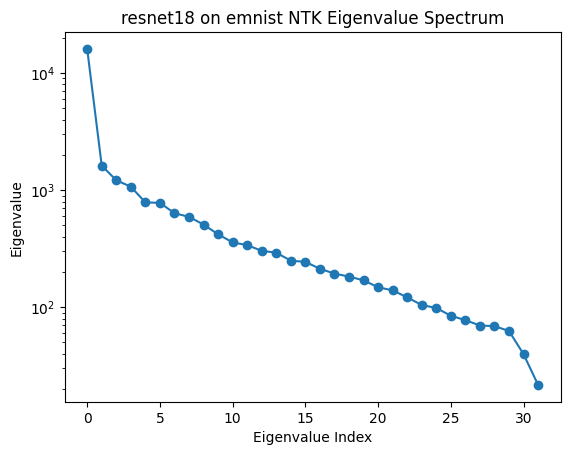

Analyzing activation ranks...
Layer conv1: effective rank = 7 (max possible 64)
Layer layer1: effective rank = 39 (max possible 64)
Layer layer2: effective rank = 108 (max possible 128)
Layer layer3: effective rank = 239 (max possible 256)
Layer layer4: effective rank = 339 (max possible 512)
Layer avgpool: effective rank = 32 (max possible 512)


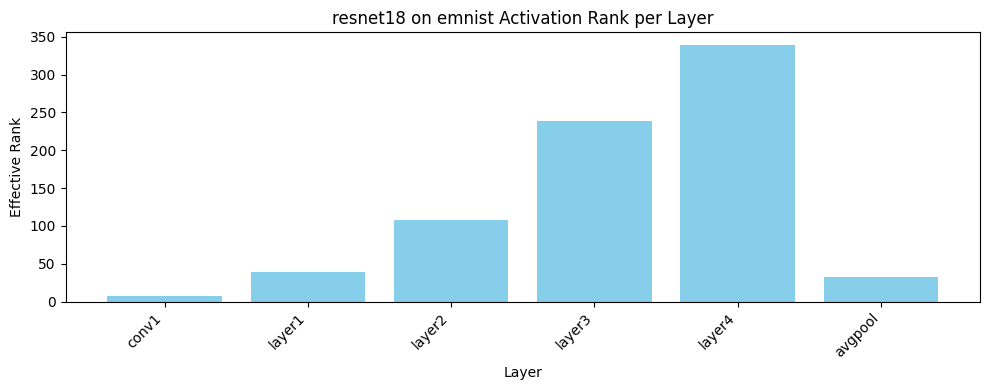

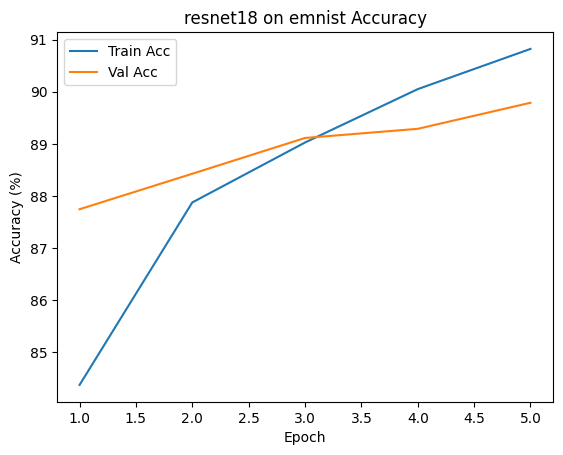


=== Running experiment: vit_b16 on emnist ===
Epoch 01: Train Loss=2.3321, Acc=32.77% | Val Loss=1.2633, Acc=59.16% | Time=776.58s
Epoch 02: Train Loss=0.8160, Acc=73.06% | Val Loss=0.6155, Acc=79.17% | Time=858.44s
Epoch 03: Train Loss=0.5448, Acc=81.14% | Val Loss=0.5113, Acc=83.14% | Time=685.36s
Epoch 04: Train Loss=0.4527, Acc=83.99% | Val Loss=0.4356, Acc=85.30% | Time=574.50s
Epoch 05: Train Loss=0.4041, Acc=85.55% | Val Loss=0.4206, Acc=85.47% | Time=561.82s
NTK eigenvalues: [2264.0725    706.8295    600.8089    443.9481    345.05432   290.0423
  272.92477   230.02763   208.77638   195.18918   189.90405   184.27826
  164.84955   147.05779   143.79665   126.303925  112.973404  107.2422
  103.75864    94.942184   93.70485    85.477394   78.30059    72.510895
   70.044395   65.75849    58.63105    55.819912   49.81938    43.56136
   40.329536   36.18185 ]


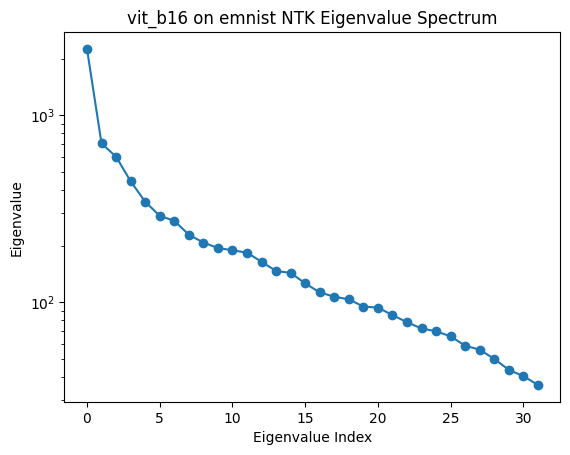

Analyzing activation ranks...
Layer encoder.ln: effective rank = 93 (max possible 768)


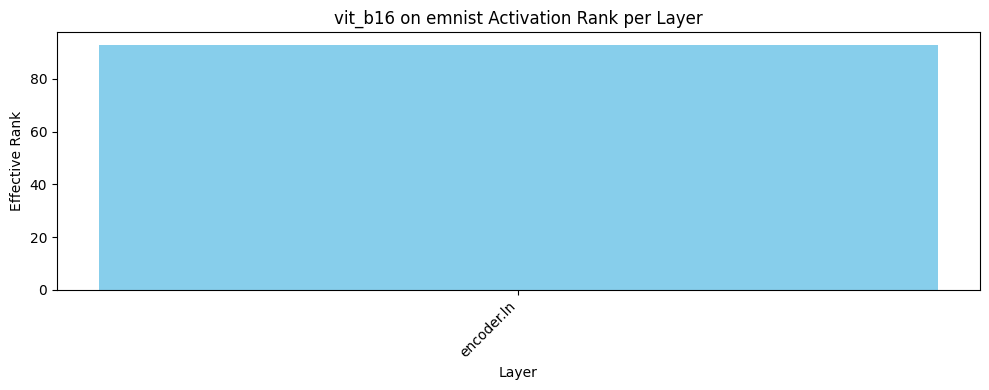

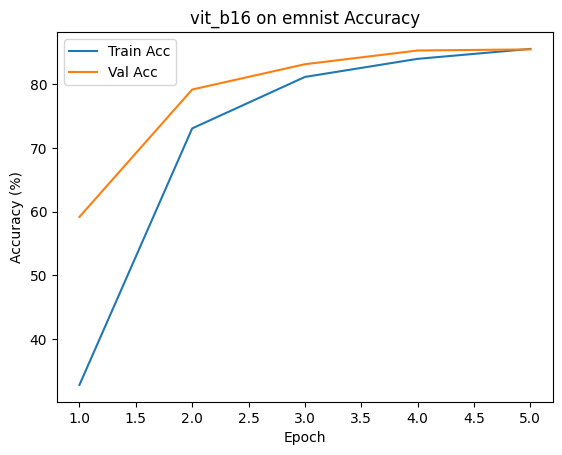


=== Running experiment: resnet18 on cifar100 ===


100%|██████████| 169M/169M [00:04<00:00, 36.6MB/s] 


Epoch 01: Train Loss=2.3292, Acc=38.40% | Val Loss=1.7329, Acc=51.64% | Time=63.59s
Epoch 02: Train Loss=1.4454, Acc=58.68% | Val Loss=1.3761, Acc=60.74% | Time=63.74s
Epoch 03: Train Loss=1.0666, Acc=68.28% | Val Loss=1.3770, Acc=62.93% | Time=63.93s
Epoch 04: Train Loss=0.7622, Acc=76.54% | Val Loss=1.2554, Acc=65.65% | Time=63.79s
Epoch 05: Train Loss=0.5278, Acc=83.14% | Val Loss=1.3764, Acc=65.51% | Time=63.56s
NTK eigenvalues: [61339.586  12084.4795  9637.038   8677.7     8431.747   7205.1284
  6452.224   5383.857   5163.4844  4809.065   4462.7417  4238.811
  4015.2246  3745.1013  3622.2017  3440.5078  3131.4734  3005.1177
  2888.23    2789.309   2631.7986  2595.3628  2477.5178  2272.0588
  2236.94    2149.089   1959.6772  1812.461   1722.4777  1531.8551
  1381.2852  1111.3068]


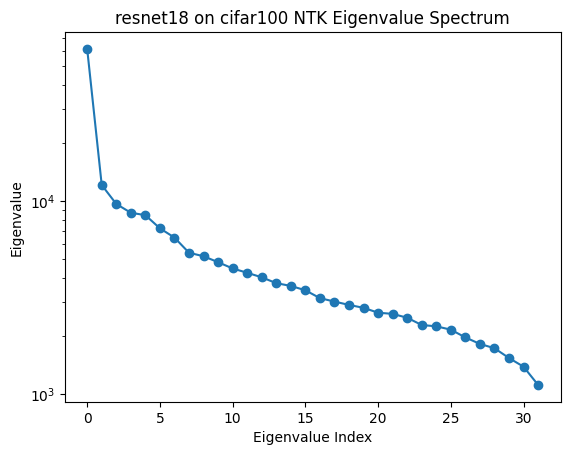

Analyzing activation ranks...
Layer conv1: effective rank = 11 (max possible 64)
Layer layer1: effective rank = 57 (max possible 64)
Layer layer2: effective rank = 128 (max possible 128)
Layer layer3: effective rank = 256 (max possible 256)
Layer layer4: effective rank = 356 (max possible 512)
Layer avgpool: effective rank = 32 (max possible 512)


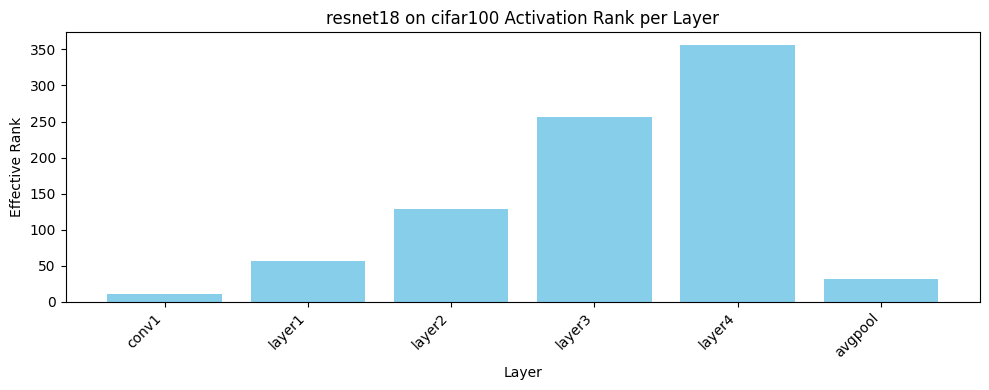

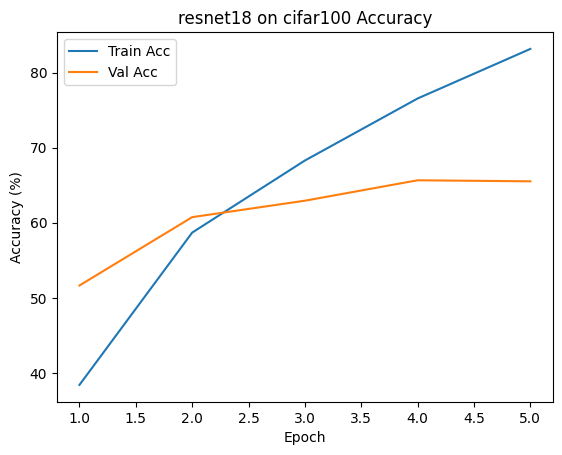


=== Running experiment: vit_b16 on cifar100 ===
Epoch 01: Train Loss=3.8992, Acc=9.88% | Val Loss=3.5151, Acc=15.91% | Time=247.92s
Epoch 02: Train Loss=3.3450, Acc=18.61% | Val Loss=3.2187, Acc=21.83% | Time=246.66s
Epoch 03: Train Loss=3.1303, Acc=22.75% | Val Loss=3.2242, Acc=21.96% | Time=248.11s
Epoch 04: Train Loss=2.9123, Acc=26.86% | Val Loss=2.8438, Acc=28.40% | Time=247.27s
Epoch 05: Train Loss=2.6934, Acc=31.19% | Val Loss=2.7577, Acc=30.44% | Time=247.20s
NTK eigenvalues: [1718.8773    317.83737   255.19449   190.36842   182.62753   141.16254
  126.84867   118.06509   106.24128    98.757576   90.21024    79.175674
   76.433426   63.733936   60.28149    56.27784    53.650555   49.608097
   47.785286   40.924244   39.777256   36.981083   33.487698   31.993488
   31.184742   27.186094   25.877235   23.782988   19.247658   16.36502
   15.610354   15.145532]


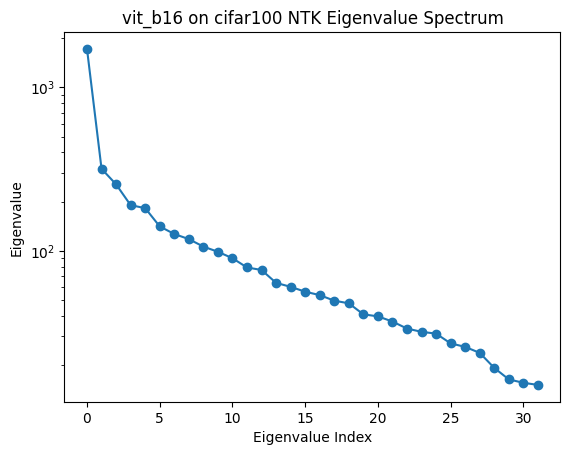

Analyzing activation ranks...
Layer encoder.ln: effective rank = 120 (max possible 768)


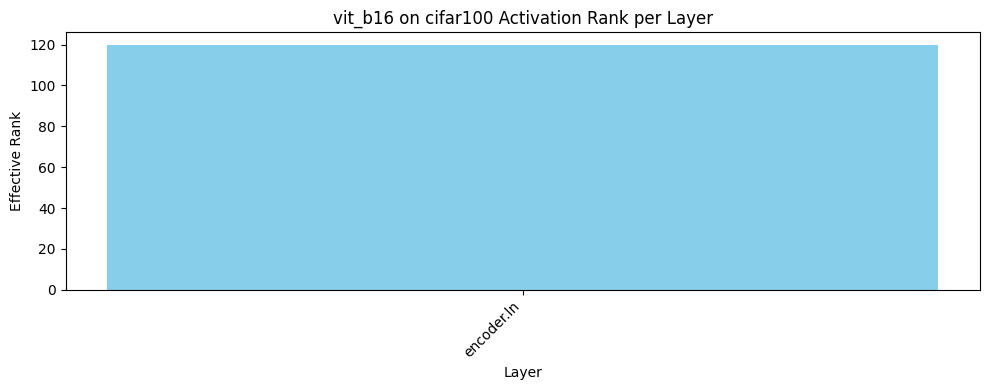

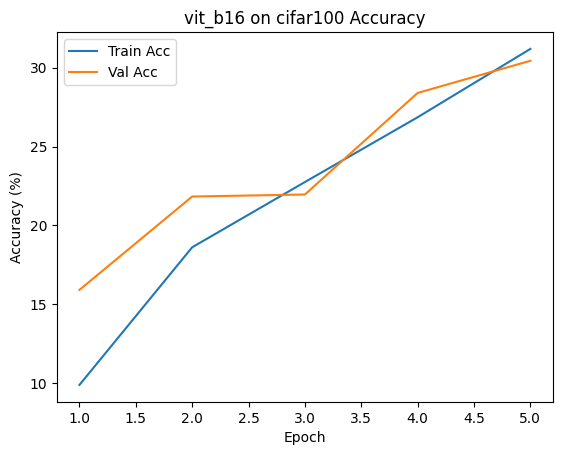


=== Running experiment: resnet18 on cifar10 ===
Epoch 01: Train Loss=0.6674, Acc=77.35% | Val Loss=0.5009, Acc=83.24% | Time=62.72s
Epoch 02: Train Loss=0.3963, Acc=86.46% | Val Loss=0.3909, Acc=86.59% | Time=62.98s
Epoch 03: Train Loss=0.2871, Acc=90.16% | Val Loss=0.3614, Acc=87.83% | Time=63.18s
Epoch 04: Train Loss=0.2145, Acc=92.60% | Val Loss=0.3289, Acc=88.88% | Time=63.27s
Epoch 05: Train Loss=0.1542, Acc=94.62% | Val Loss=0.3813, Acc=88.72% | Time=63.41s
NTK eigenvalues: [45190.492    9597.823    6195.652    5292.6484   4135.5225   4001.6675
  3417.1196   2735.077    2471.3752   2375.3716   2143.3328   2060.7332
  1840.1008   1698.5121   1633.9004   1520.1517   1405.3951   1336.5297
  1231.9945   1204.3801   1123.5839   1101.373     983.3677    962.5938
   900.213     869.68835   798.92      754.98016   738.3535    705.401
   634.5035    585.5395 ]


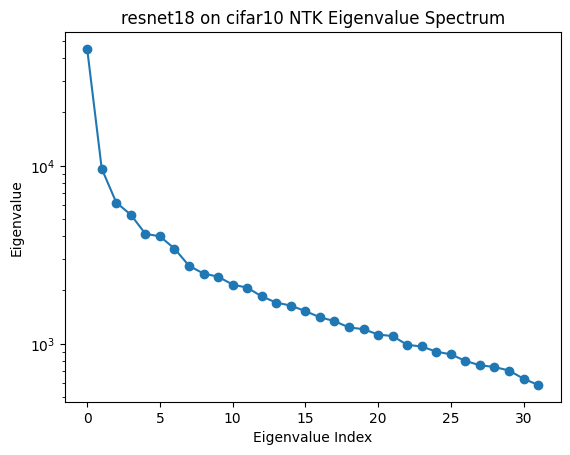

Analyzing activation ranks...
Layer conv1: effective rank = 12 (max possible 64)
Layer layer1: effective rank = 57 (max possible 64)
Layer layer2: effective rank = 127 (max possible 128)
Layer layer3: effective rank = 255 (max possible 256)
Layer layer4: effective rank = 168 (max possible 512)
Layer avgpool: effective rank = 32 (max possible 512)


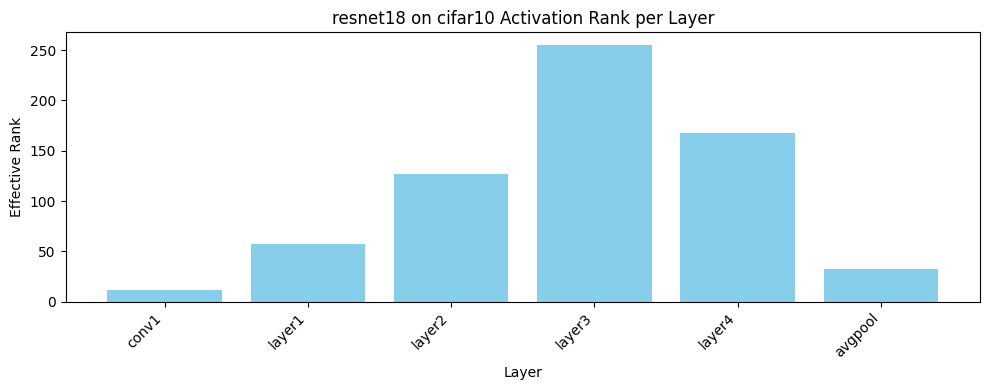

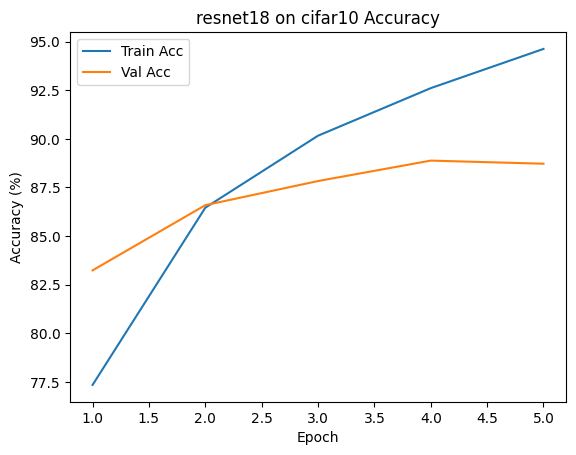


=== Running experiment: vit_b16 on cifar10 ===
Epoch 01: Train Loss=1.7945, Acc=32.64% | Val Loss=1.6123, Acc=39.29% | Time=246.63s
Epoch 02: Train Loss=1.4803, Acc=45.45% | Val Loss=1.4334, Acc=47.74% | Time=247.25s
Epoch 03: Train Loss=1.3539, Acc=50.75% | Val Loss=1.3819, Acc=49.93% | Time=246.70s
Epoch 04: Train Loss=1.2601, Acc=54.32% | Val Loss=1.2441, Acc=55.38% | Time=247.32s
Epoch 05: Train Loss=1.1792, Acc=57.45% | Val Loss=1.1729, Acc=57.86% | Time=247.22s
NTK eigenvalues: [1263.2838     260.9354     214.15187    151.70856    121.122795
  105.50483     83.840195    68.747505    60.05489     52.720375
   46.489952    40.856667    39.828598    33.54017     28.050562
   25.583836    24.130814    20.789549    19.453857    18.154896
   17.537182    16.741333    14.260733    12.896443    11.5386915
   10.56377      9.405785     8.744326     7.953322     6.9998345
    6.502192     5.798939 ]


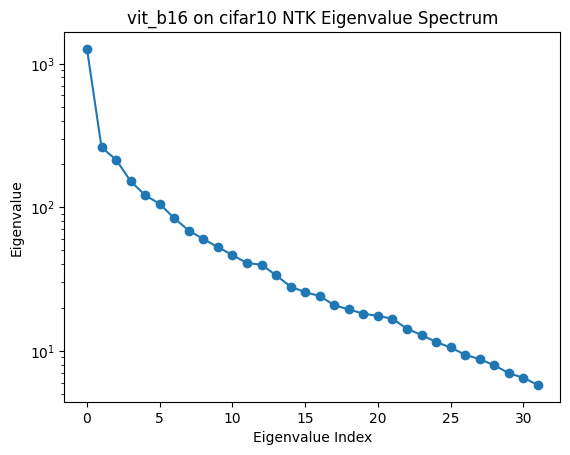

Analyzing activation ranks...
Layer encoder.ln: effective rank = 105 (max possible 768)


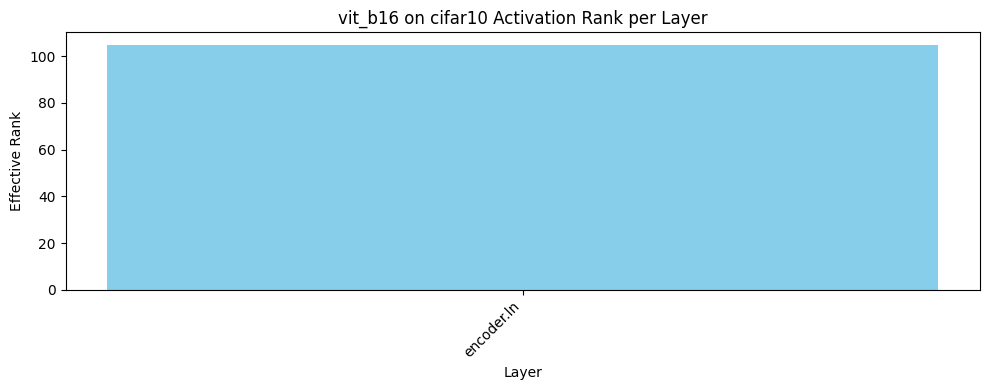

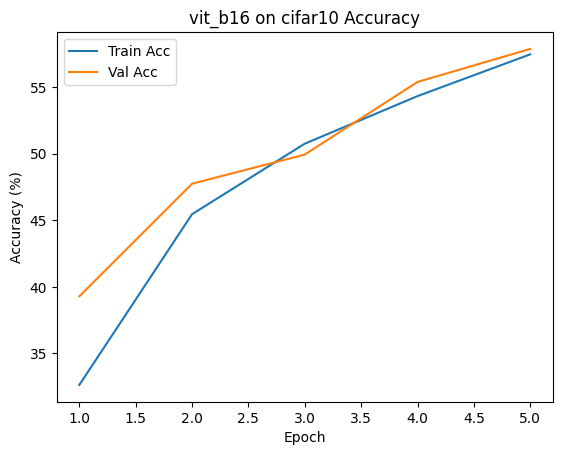


=== Running experiment: resnet18 on mnist ===
Epoch 01: Train Loss=0.0774, Acc=97.68% | Val Loss=0.0496, Acc=98.38% | Time=76.55s
Epoch 02: Train Loss=0.0436, Acc=98.68% | Val Loss=0.0228, Acc=99.34% | Time=76.48s
Epoch 03: Train Loss=0.0332, Acc=99.02% | Val Loss=0.0302, Acc=98.99% | Time=77.31s
Epoch 04: Train Loss=0.0286, Acc=99.17% | Val Loss=0.0217, Acc=99.39% | Time=77.51s
Epoch 05: Train Loss=0.0223, Acc=99.34% | Val Loss=0.0235, Acc=99.31% | Time=77.17s
NTK eigenvalues: [16624.03      3717.0696    2706.151     2030.6647    1193.9083
   841.5242     833.1164     692.8854     410.64233    232.78963
   230.65509    208.95128    153.76675    131.50693    129.5964
   113.93825    102.9931      93.414734    89.89522     76.16489
    73.504395    64.20454     60.619843    59.098824    52.35494
    47.776325    43.35725     39.39266     36.703854    34.253033
    30.529106    24.911293]


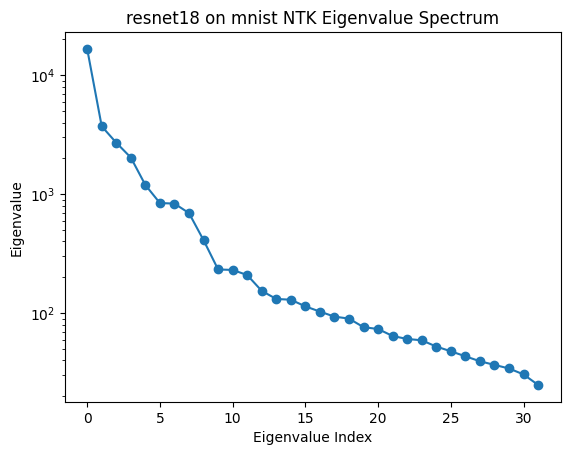

Analyzing activation ranks...
Layer conv1: effective rank = 8 (max possible 64)
Layer layer1: effective rank = 40 (max possible 64)
Layer layer2: effective rank = 112 (max possible 128)
Layer layer3: effective rank = 228 (max possible 256)
Layer layer4: effective rank = 165 (max possible 512)
Layer avgpool: effective rank = 28 (max possible 512)


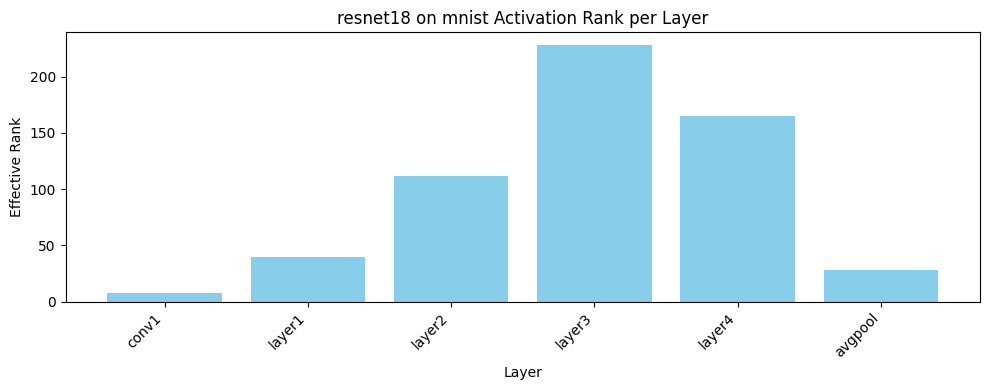

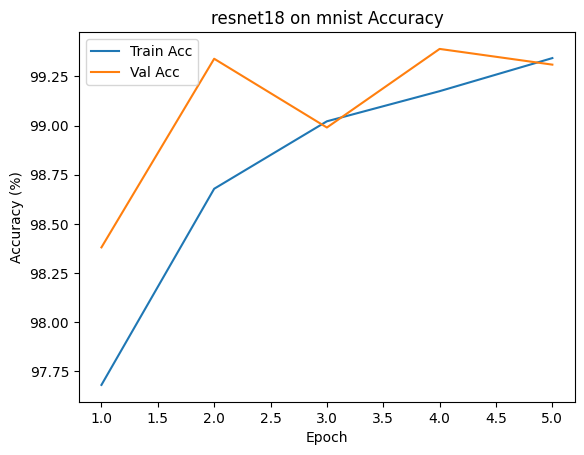


=== Running experiment: vit_b16 on mnist ===
Epoch 01: Train Loss=1.3675, Acc=48.49% | Val Loss=0.6370, Acc=78.56% | Time=294.23s
Epoch 02: Train Loss=0.4594, Acc=84.58% | Val Loss=0.3104, Acc=89.93% | Time=294.36s
Epoch 03: Train Loss=0.2257, Acc=92.79% | Val Loss=0.1421, Acc=95.51% | Time=295.30s
Epoch 04: Train Loss=0.1446, Acc=95.35% | Val Loss=0.1380, Acc=95.81% | Time=294.61s
Epoch 05: Train Loss=0.1145, Acc=96.30% | Val Loss=0.1336, Acc=95.90% | Time=295.19s
NTK eigenvalues: [4268.3423   1102.784     904.30365   722.53046   649.6295    514.054
  468.71588   398.25125   363.2418    302.68332   247.37512   229.78789
  224.23383   191.16216   176.39583   171.12863   162.0709    138.5568
  117.010475  114.19692   109.52068   106.64294    98.5006     89.17943
   84.73922    76.922775   74.770805   62.356876   61.508213   53.741646
   50.66451    39.909973]


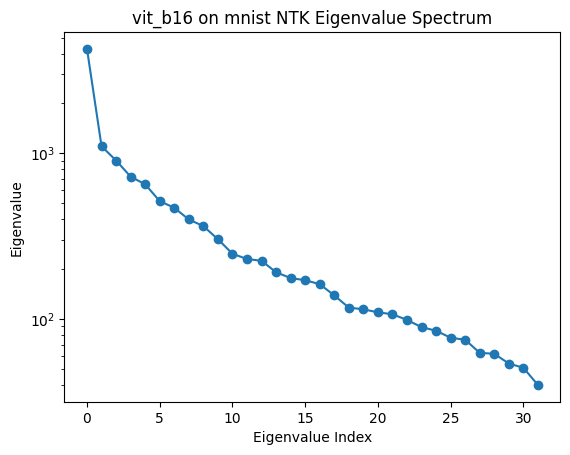

Analyzing activation ranks...
Layer encoder.ln: effective rank = 100 (max possible 768)


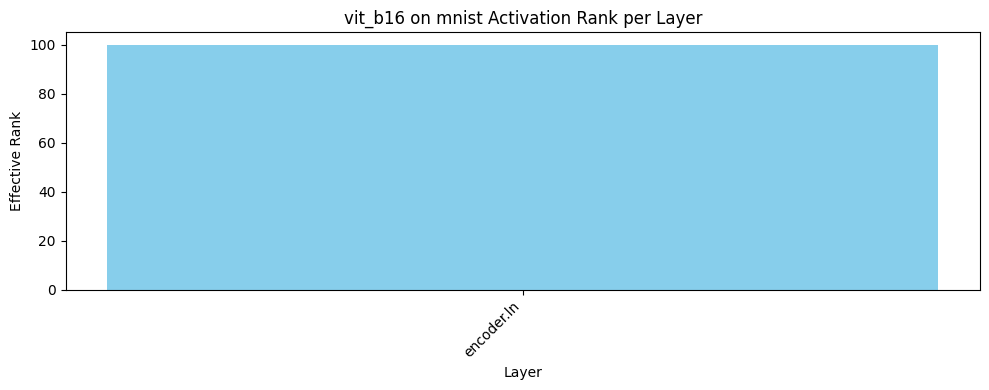

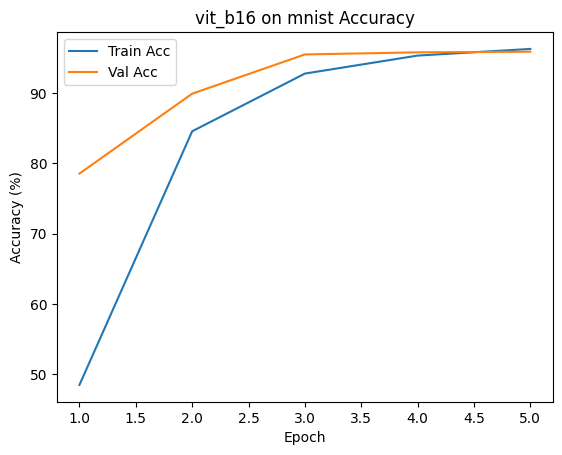


=== Final Validation Accuracies ===
resnet18_emnist: 89.79%
vit_b16_emnist: 85.47%
resnet18_cifar100: 65.51%
vit_b16_cifar100: 30.44%
resnet18_cifar10: 88.72%
vit_b16_cifar10: 57.86%
resnet18_mnist: 99.31%
vit_b16_mnist: 95.90%


In [ ]:
experiments = [
    ("resnet18", "emnist"),
    ("vit_b16", "emnist"),
    ("resnet18", "cifar100"),
    ("vit_b16", "cifar100"),
    ("resnet18", "cifar10"),
    ("vit_b16", "cifar10"),
    ("resnet18", "mnist"),
    ("vit_b16", "mnist")
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = {}

for model_name, dataset_name in experiments:
    res = run_experiment(model_name, dataset_name, batch_size=32, epochs=5, lr=1e-3, device=device)
    results[f"{model_name}_{dataset_name}"] = res

print("\n=== Final Validation Accuracies ===")
for key, val in results.items():
    print(f"{key}: {val['final_val_acc']:.2f}%")